In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False) # 抗生素欄位清單

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [9]:
data_filter.head(6)

,ACCOUNTNO,INFECTIONSITE1,INFECTIONSITE2,INFECTIONSITE3,INFECTIONSITE4,INFECTIONSITE5,INFECTIONSITE9,OTHERINFECTIONSITE_flag,ROOMNO,AGE,SEX,StayTime_hours,INTIME,ISSEPSIS0,VITALSIGNSBT,VITALSIGNSPR,VITALSIGNSRR,VITALSIGNSSPO2,VITALSIGNSDBP,VITALSIGNSGCS,MAP,FEVER,INJURELEVEL,DM,CARDIOVASCULAR,RESPIRATORY,CNS,CANCER,LIVER,KIDNEY,AUTOIMMUNE,Hb,WBC,Ht,PLT,Lymphocyte,Neutrophil Seg.,Absolute Neutrophil count,Na,K,Creatinine,GPT,CRP,HST,Leukocyte level,Nitrite level,Bacteria level,Microscopic RBC level,Microscopic WBC level,PH,Influenza Virus A level,T.Bilirubin,PT,INR,APTT,PCO2,HCO3,BE(ecf),O2 SAT,FIRST_ORDERTIME,CHECKITEM28A,CHECKITEM27,CHECKITEM27SCORE,CHECKITEM28SCORE,CHECKITEM29SCORE,CHECKITEM30SCORE,CHECKITEM31SCORE,CHECKITEM32SCORE,Amoxicillin/Clavulanic acid,Ampicillin,Azithromycin,Baloxavir marboxil,Cefadroxil,Cefazolin,Cefixime,Cefoperazone/sulbactam,Ceftriaxone,Cefuroxime,Cephalexin,Ciprofloxacin,Clindamycin,Flomoxef,Gentamicin,Levofloxacin,Metronidazole,Oseltamivir,Peramivir,Piperacillin/Tazobactam,Miss_INFECTSITE_flag
0,I11300000002,1,0,0,0,0,0,0,A,65.0,M,0.261944,2024-01-01 00:47:17,N,38.2,106.0,20.0,95.0,93.0,15.0,113.0,Y,3.0,N,Y,Y,Y,N,Y,Y,Y,12.5,11.86,34.1,178.0,6.1,86.4,10247.0,137.0,3.3,1.20,50.0,14.768,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,I11300000003,0,0,0,0,0,0,0,C,48.0,F,0.460833,2024-01-01 00:50:21,N,36.4,88.0,20.0,NaN,85.0,15.0,105.0,Y,4.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,I11300000008,0,0,0,0,0,0,0,A,19.0,F,2.628056,2024-01-01 01:17:19,N,37.6,120.0,18.0,NaN,62.0,15.0,73.0,Y,3.0,N,N,N,N,N,N,N,N,11.4,7.32,34.6,194.0,19.6,68.6,5234.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,1.0,2.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,I11300000011,0,0,0,0,0,0,0,A,16.0,M,3.546944,2024-01-01 01:25:11,N,36.3,118.0,18.0,NaN,64.0,15.0,77.0,Y,3.0,N,N,Y,N,N,Y,Y,Y,17.4,16.01,48.2,300.0,8.1,84.4,13512.0,136.0,3.6,0.78,19.0,0.929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,I11300000014,0,0,0,0,0,0,0,A,22.0,F,2.638056,2024-01-01 03:03:43,N,36.9,103.0,18.0,NaN,61.0,15.0,74.0,Y,3.0,N,N,N,N,N,N,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
5,I11300000015,0,0,1,1,0,0,0,C,35.0,M,4.690278,2024-01-01 03:23:35,N,36.2,49.0,18.0,NaN,59.0,3.0,88.0,Y,1.0,N,N,N,N,N,N,N,N,13.9,17.59,41.0,184.0,4.7,87.6,16411.0,147.0,4.1,1.16,49.0,16.780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.6,1.05,28.0,60.0,23.9,-1.6,99.8,2024-01-01 03:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols] # 特徵欄位
y = data_filter[final_cols] # 藥物欄位

In [13]:
X.shape, y.shape

((27968, 69), (27968, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")


原本樣本數: 27968
過濾後樣本數: 22509
已刪除 5459 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['DM', 'RESPIRATORY', 'GPT', 'INFECTIONSITE5', 'CHECKITEM27SCORE', 'WBC',
       'PH', 'Ht', 'CHECKITEM28SCORE', 'Lymphocyte', 'VITALSIGNSDBP', 'PCO2',
       'INFECTIONSITE1', 'O2 SAT', 'CHECKITEM27', 'INR', 'VITALSIGNSPR', 'PT',
       'HST', 'Microscopic WBC level', 'Microscopic RBC level',
       'VITALSIGNSGCS', 'FEVER', 'LIVER', 'INFECTIONSITE9', 'Neutrophil Seg.',
       'Na', 'BE(ecf)', 'Bacteria level', 'VITALSIGNSRR', 'CNS',
       'CHECKITEM30SCORE', 'OTHERINFECTIONSITE_flag',
       'Absolute Neutrophil count', 'Miss_INFECTSITE_flag', 'APTT',
       'AUTOIMMUNE', 'StayTime_hours', 'INFECTIONSITE2', 'Hb',
       'CHECKITEM29SCORE', 'Nitrite level', 'Creatinine', 'CHECKITEM28A',
       'CHECKITEM31SCORE', 'CARDIOVASCULAR', 'KIDNEY', 'PLT', 'K',
       'Leukocyte level', 'AGE', 'INJURELEVEL', 'MAP', 'CRP', 'SEX',
       'VITALSIGNSBT', 'INFECTIONSITE4', 'HCO3', 'T.Bilirubin',
       'VITALSIGNSSPO2', 'CHECKITEM32SCORE', 'INFECTIONSITE3', 'CANCER'],
      dtype='object')

In [17]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


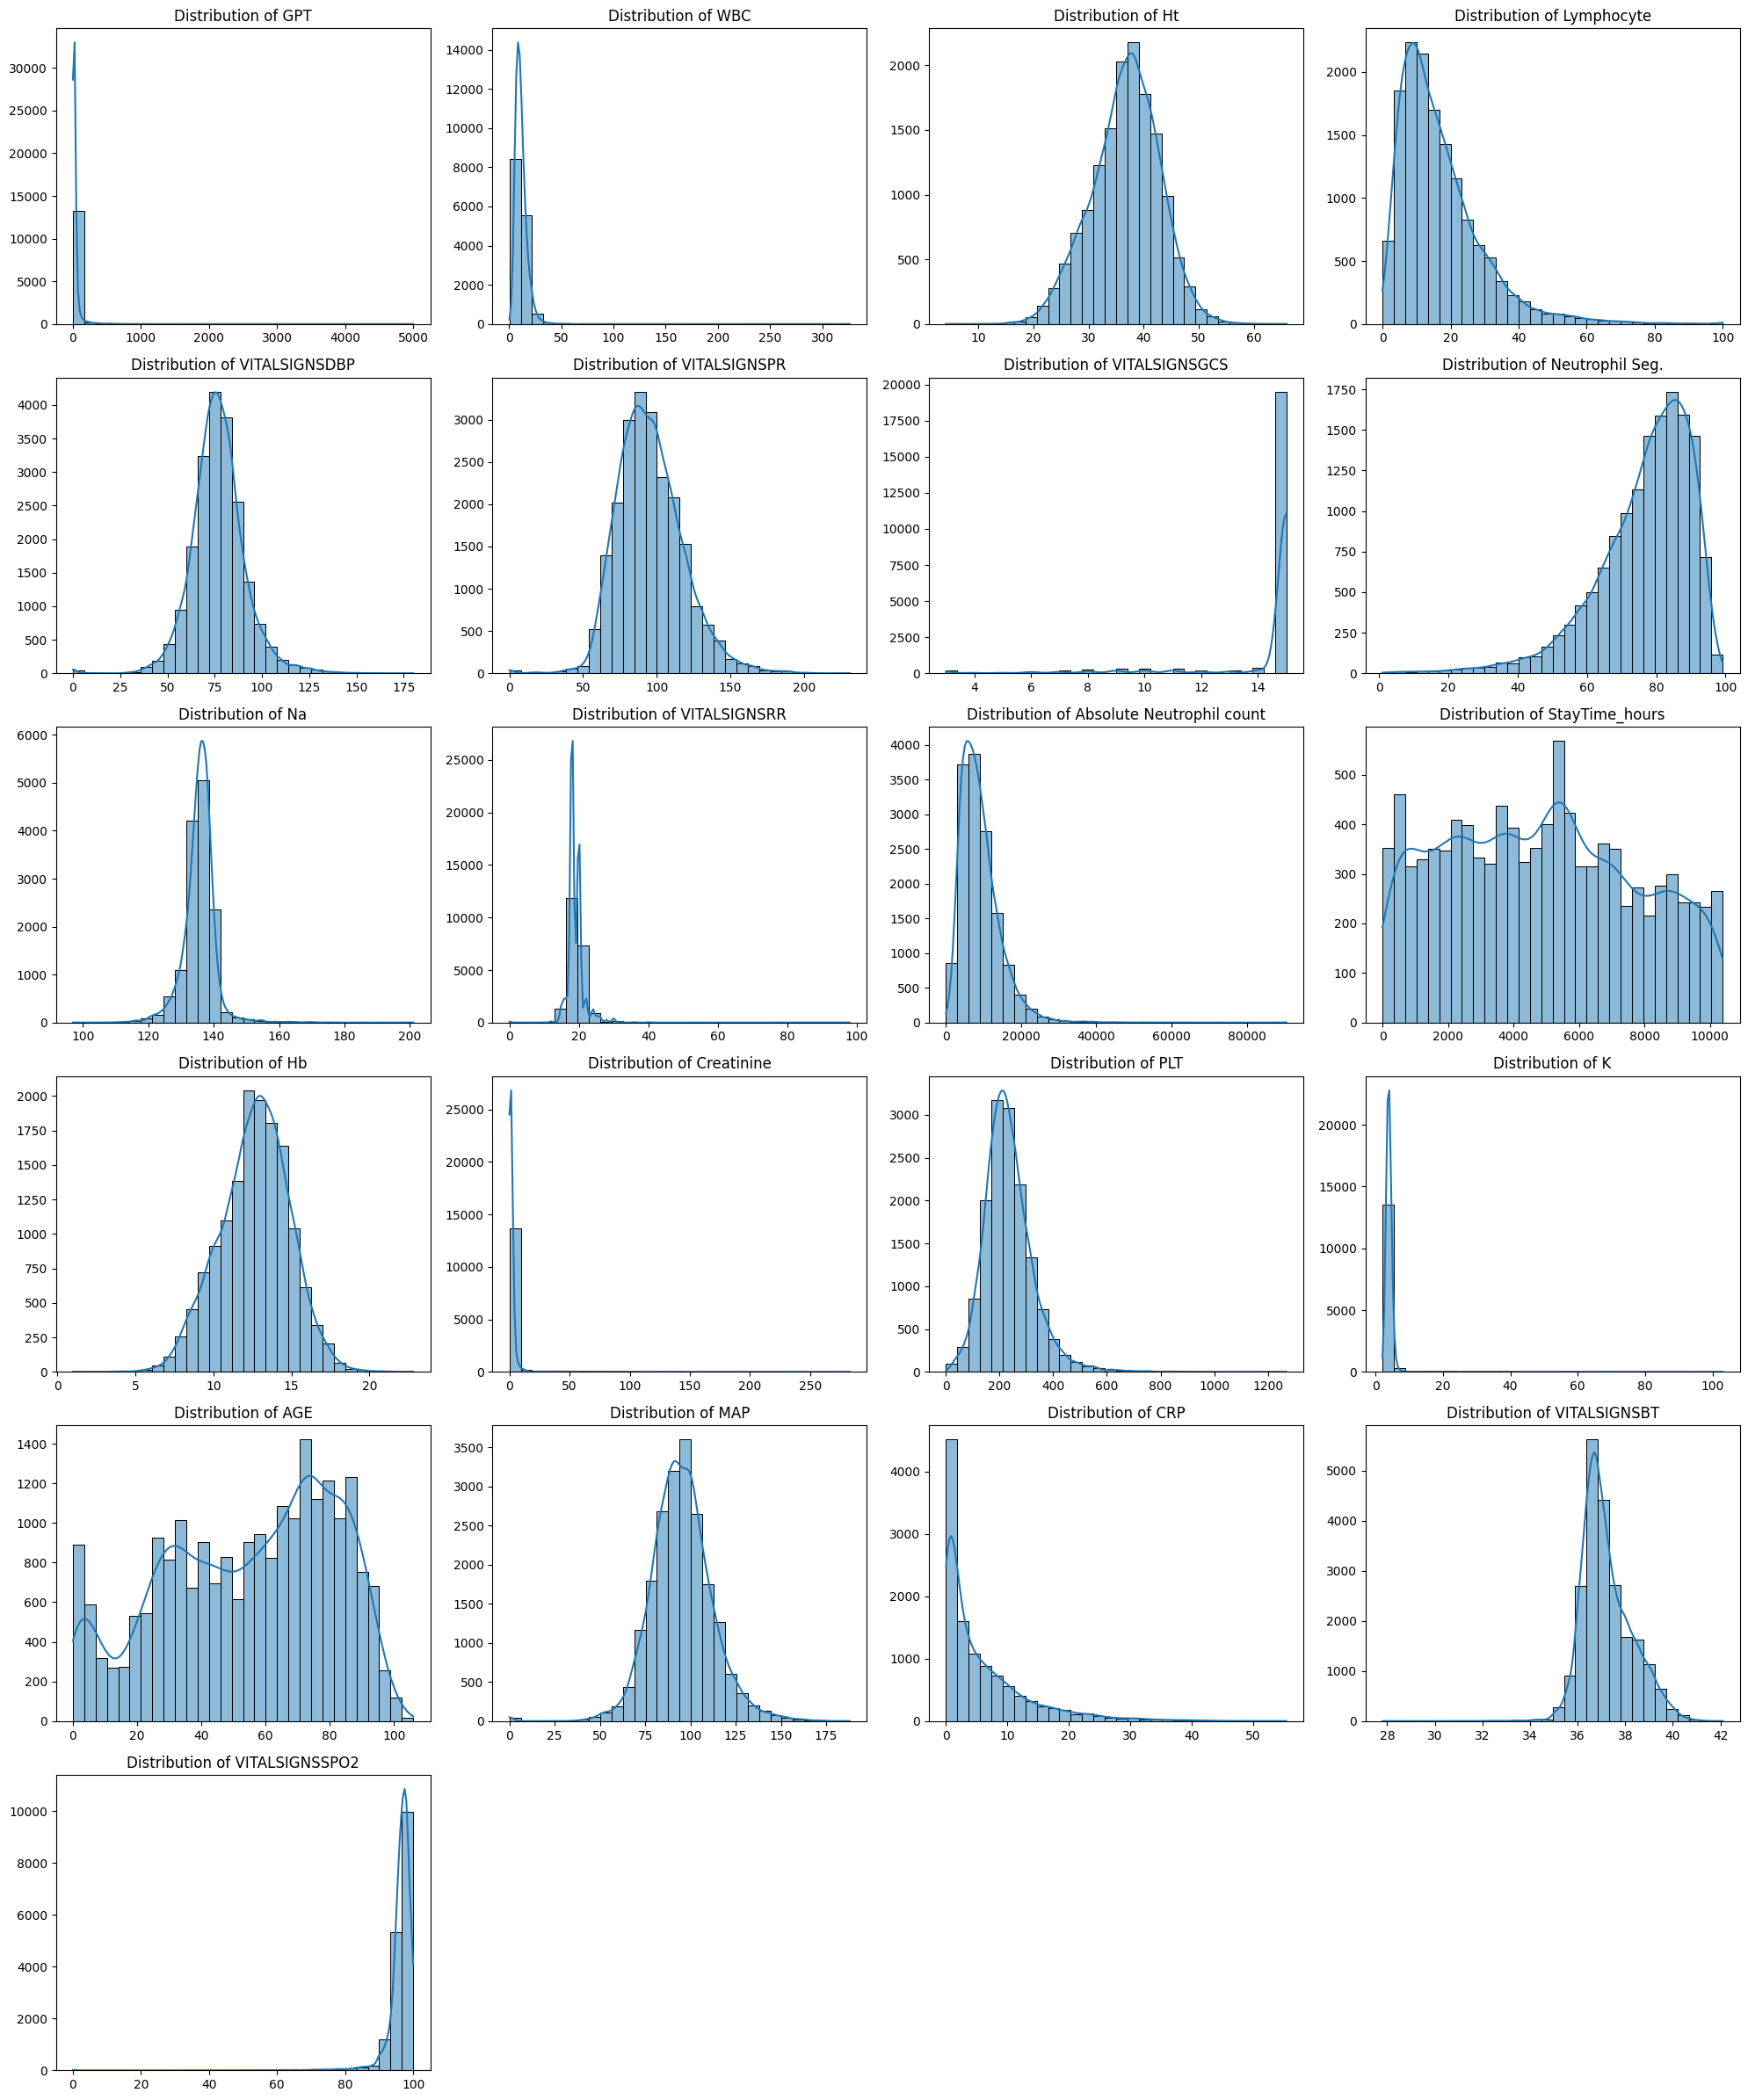

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 6941

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              201                   202   
VITALSIGNSBT                              190                   196   
MAP                                       200                   185   
VITALSIGNSDBP                             188                   190   
VITALSIGNSRR                              109                   216   
WBC                                       147                   147   
PLT                                       144                   147   
Absolute Neutrophil count                 145                   145   
Neutrophil Seg.                           144                   144   
Ht                                        143                   144   

                           Total_Outliers  
VITALSIGNSPR                          403  
VITALSIGNSBT                          386  
MAP                                   385  
VITAL

In [20]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((20258, 86), (20258, 15), (2251, 86), (2251, 15))

In [22]:
X_train.isnull().sum(), X_test.isnull().sum()

(DM                           0
 RESPIRATORY                  0
 GPT                       7952
 INFECTIONSITE5               0
 CHECKITEM27SCORE         16254
                          ...  
 CHECKITEM27_flag             0
 CHECKITEM27SCORE_flag        0
 CHECKITEM28SCORE_flag        0
 CHECKITEM31SCORE_flag        0
 CHECKITEM32SCORE_flag        0
 Length: 86, dtype: int64,
 DM                          0
 RESPIRATORY                 0
 GPT                       882
 INFECTIONSITE5              0
 CHECKITEM27SCORE         1824
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 86, dtype: int64)

In [23]:
X_train.dtypes, X_test.dtypes

(DM                         int64
 RESPIRATORY                int64
 GPT                      float64
 INFECTIONSITE5             int64
 CHECKITEM27SCORE         float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 86, dtype: object,
 DM                         int64
 RESPIRATORY                int64
 GPT                      float64
 INFECTIONSITE5             int64
 CHECKITEM27SCORE         float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 86, dtype: object)

In [24]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4953.0
Flomoxef                       4683.0
Cefazolin                      2137.0
Cefixime                       1950.0
Ciprofloxacin                  1873.0
Azithromycin                   1870.0
Cefuroxime                     1521.0
Piperacillin/Tazobactam        1352.0
Cefoperazone/sulbactam         1281.0
Metronidazole                   901.0
Levofloxacin                    642.0
Clindamycin                     564.0
Gentamicin                      563.0
Ceftriaxone                     530.0
Ampicillin                      390.0
dtype: float64

In [25]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [26]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [27]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [28]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [29]:
y_train.sum(axis=1).mean() # 每人平均用1.24個抗生素

np.float64(1.2444466383650903)

In [30]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [31]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [32]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(20258, 63)

In [33]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [34]:
X_train.columns

Index(['DM', 'RESPIRATORY', 'GPT', 'INFECTIONSITE5', 'WBC', 'Ht', 'Lymphocyte',
       'VITALSIGNSDBP', 'INFECTIONSITE1', 'VITALSIGNSPR', 'VITALSIGNSGCS',
       'FEVER', 'LIVER', 'INFECTIONSITE9', 'Neutrophil Seg.', 'Na',
       'VITALSIGNSRR', 'CNS', 'OTHERINFECTIONSITE_flag',
       'Absolute Neutrophil count', 'Miss_INFECTSITE_flag', 'AUTOIMMUNE',
       'StayTime_hours', 'INFECTIONSITE2', 'Hb', 'Creatinine',
       'CARDIOVASCULAR', 'KIDNEY', 'PLT', 'K', 'AGE', 'INJURELEVEL', 'MAP',
       'CRP', 'SEX', 'VITALSIGNSBT', 'INFECTIONSITE4', 'VITALSIGNSSPO2',
       'INFECTIONSITE3', 'CANCER', 'Leukocyte level_flag',
       'Nitrite level_flag', 'Bacteria level_flag',
       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
       'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', 'HST_flag',
       'T.Bilirubin_flag', 'PT_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag',
       'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
       'CHECKITEM27_flag', '

In [35]:
# LogisticRegressionCV?
# XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

In [36]:
calibrated_models = []

for i, col in enumerate(y_train.columns): # or for i in range(y_train.shape[1])
    base_model = XGBClassifier(n_estimators=300,
                               max_depth=5,
                               learning_rate=0.05,
                               subsample=0.8,
                               colsample_bytree=0.8,
                               eval_metric='logloss',
                               gamma=0,
                               reg_alpha=2.0,
                               reg_lambda=0.0,
                               min_child_weight=1,
                               scale_pos_weight=2,
                               random_state =123,
                               n_jobs=-1 )
    
    calibrated = CalibratedClassifierCV(
        base_model,
        method='isotonic',  # or 'sigmoid'、'isotonic'
        cv=3
    )

    calibrated.fit(X_train, y_train.iloc[:, i])
    calibrated_models.append(calibrated)

In [37]:
# # # 原始機率
y_prob_list = np.column_stack([model.predict_proba(X_test)[:, 1] for model in calibrated_models])

# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
f1_per_label = []

for i in range(y_train.shape[1]):
    y_train_pred = calibrated_models[i].predict(X_train)
    f1 = f1_score(y_train.iloc[:, i], y_train_pred)
    f1_per_label.append(f1)

drug_weight = 1 / (np.array(f1_per_label) + 1e-3)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.01 # penalty
belta = 0.9

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = (np.log(y_prob_list + 1e-8)+ beta * np.log(drug_weight)- alpha * np.log(drug_freq))
adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)

# 用adjusted_scores排序(Top-K核心)
k=3
topk_idx = np.argsort(adjusted_scores, axis=1)[:, -k:]

# 建立 prediction matrix（for metric）
y_pred_matrix = np.zeros_like(y_prob_list)

for i in range(len(y_prob_list)):
    y_pred_matrix[i, topk_idx[i]] = 1

In [38]:
drug_weight

array([0.19616019, 0.14834739, 0.63091823, 0.1724401 , 2.25516388,
       6.14755626, 0.29754703, 2.38287202, 0.5948792 , 0.36864746,
       0.17876715, 0.18660865, 0.82127743, 0.31571495, 0.30310005])

In [39]:
drug_weight ** belta

array([0.23086058, 0.17953615, 0.66065659, 0.20557696, 2.0790278 ,
       5.12663338, 0.33589231, 2.18469415, 0.62659353, 0.40733349,
       0.21235326, 0.22071843, 0.83760816, 0.35429549, 0.34152886])

In [40]:
print(f1_score(y_test, y_pred_matrix, average='micro'))
print(f1_score(y_test, y_pred_matrix, average='macro'))

0.37365169127657344
0.4173478261075931


In [41]:
jaccard_score(y_test, y_pred_matrix, average='samples', zero_division=0)

np.float64(0.25366503776099514)

In [42]:
hamming_loss(y_test, y_pred_matrix)

0.1771360876647416

In [43]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

hit3 = hit_rate_at_k(y_test.values, adjusted_scores, k=5)
print('Hit@3: ', hit3)
precision3 = precision_at_k(y_test.values, adjusted_scores, k=5)
print('precision@3: ', precision3)
recall_3 = recall_at_k(y_test.values, adjusted_scores, k=5)
print('Recall@3: ', recall_3)
map_3 = map_at_k(y_test.values, adjusted_scores, k=5)
print('MAP@3: ', map_3)

Hit@3:  0.8884940026654821
precision@3:  0.20746334962238333
Recall@3:  0.8521027691396417
MAP@3:  0.4750968705266795


In [44]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=10)

實際給藥: ['Levofloxacin']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 1.3758)
2. Levofloxacin (Score: 0.2536)
3. Cefixime (Score: 0.1403)
4. Piperacillin/Tazobactam (Score: 0.1186)
5. Azithromycin (Score: 0.1145)
6. Flomoxef (Score: 0.1058)
7. Cefuroxime (Score: 0.0718)
8. Ceftriaxone (Score: 0.0489)
9. Ciprofloxacin (Score: 0.0487)
10. Ampicillin (Score: 0.0396)
實際給藥: ['Ciprofloxacin']

推薦藥物:
1. Cefixime (Score: 0.3942)
2. Cefoperazone/sulbactam (Score: 0.2077)
3. Flomoxef (Score: 0.1702)
4. Ciprofloxacin (Score: 0.1119)
5. Metronidazole (Score: 0.1061)
6. Cefuroxime (Score: 0.0881)
7. Ceftriaxone (Score: 0.0550)
8. Piperacillin/Tazobactam (Score: 0.0516)
9. Levofloxacin (Score: 0.0500)
10. Azithromycin (Score: 0.0444)
實際給藥: ['Amoxicillin/Clavulanic acid']

推薦藥物:
1. Cefixime (Score: 0.1977)
2. Cefuroxime (Score: 0.1248)
3. Azithromycin (Score: 0.1232)
4. Amoxicillin/Clavulanic acid (Score: 0.1010)
5. Ciprofloxacin (Score: 0.0832)
6. Levofloxacin (Score: 0.0588)
7. Clindamycin (Score: 0.0475

In [45]:
y_test.head(6)

,Amoxicillin/Clavulanic acid,Ampicillin,Azithromycin,Cefazolin,Cefixime,Cefoperazone/sulbactam,Ceftriaxone,Cefuroxime,Ciprofloxacin,Clindamycin,Flomoxef,Gentamicin,Levofloxacin,Metronidazole,Piperacillin/Tazobactam
5286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2279,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17661,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
16914,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
